In [ ]:
!pip3 install plotly

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 16.3 MB 2.8 MB/s eta 0:00:01
     |████████████████████████████████| 357 kB 353 kB/s eta 0:00:01


In [36]:
import plotly.graph_objects as go
import json

# Replace this with your actual data
with open("/Users/hmmoore/Desktop/mini_dev/evaluation/path_eval_log.json", "r") as f:
    data = json.load(f)

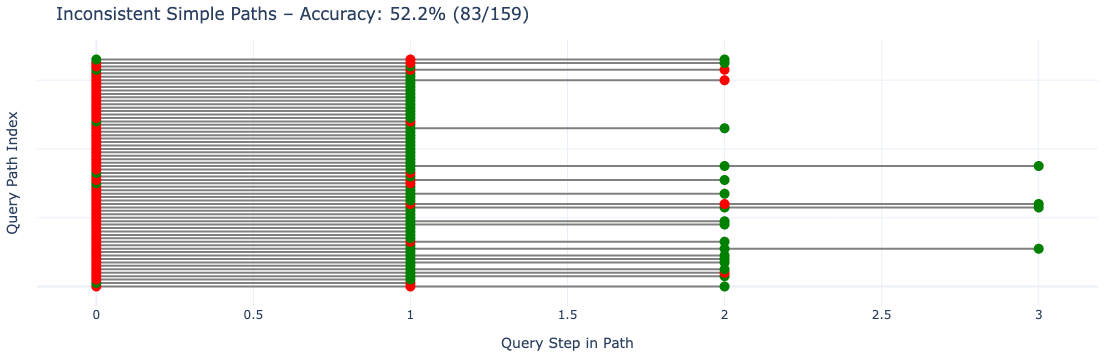

In [47]:
def plot_inconsistent_paths_by_difficulty(difficulty_level):
    fig = go.Figure()
    y_offset = 0

    def truncate(text, max_len=220):
        return text if len(text) <= max_len else text[:max_len] + "..."

    total = 0
    correct = 0

    for entry in data:
        path = entry["path"]
        if not path or path[0]["difficulty"] != difficulty_level:
            continue
        if len(path) <= 1:
            continue
        for step in path:
            if step['correct'] == None:
                step['correct'] = 0
        correct_count = sum(step['correct'] for step in path)
        if correct_count == 0 or correct_count == len(path):
            continue  # skip fully correct or fully wrong paths

        total += len(path)
        correct += correct_count

        x_vals = list(range(len(path)))
        y_vals = [y_offset] * len(path)
        colors = ['green' if step['correct'] == 1 else 'red' for step in path]
        hover_texts = [
            f"QID: {step['question_id']}<br>"
            f"<b>Difficulty:</b> {step['difficulty']}<br>"
            f"<b>Correct:</b> {'✅' if step['correct'] else '❌'}<br><br>"
            f"<b>GT:</b> {truncate(step['gt_query'])}<br><br>"
            f"<b>Pred:</b> {truncate(step['predicted_query'])}"
            for step in path
        ]

        fig.add_trace(go.Scatter(
            x=x_vals,
            y=y_vals,
            mode='lines+markers',
            marker=dict(color=colors, size=10),
            line=dict(color='gray', width=2),
            text=hover_texts,
            hoverinfo='text',
            showlegend=False
        ))

        y_offset += 1

    accuracy = (correct / total * 100) if total > 0 else 0

    fig.update_layout(
        title=f"Inconsistent {difficulty_level.capitalize()} Paths – Accuracy: {accuracy:.1f}% ({correct}/{total})",
        xaxis_title="Query Step in Path",
        yaxis_title="Query Path Index",
        yaxis=dict(showticklabels=False),
        template="plotly_white",
        height=400 + 50 * y_offset,
        margin=dict(l=20, r=20, t=40, b=20),
    )
    fig.show()

plot_inconsistent_paths_by_difficulty("simple")

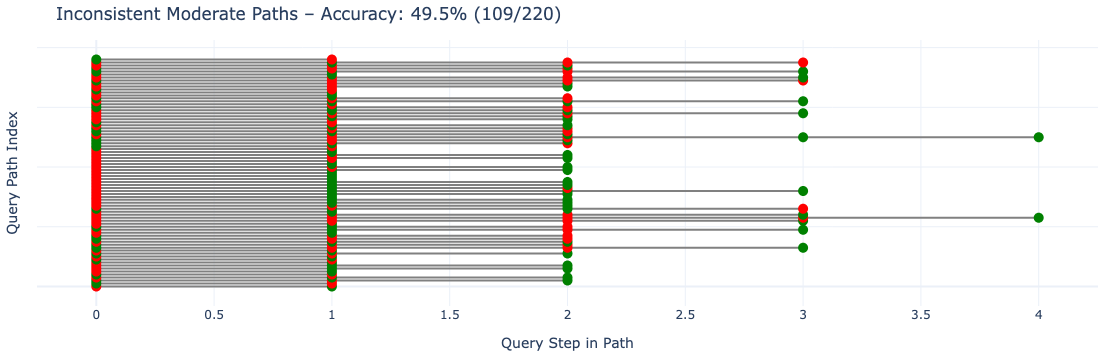

In [10]:
def plot_inconsistent_paths_by_difficulty(difficulty_level):
    fig = go.Figure()
    y_offset = 0

    def truncate(text, max_len=220):
        return text if len(text) <= max_len else text[:max_len] + "..."

    total = 0
    correct = 0

    for entry in data:
        path = entry["path"]
        if not path or path[0]["difficulty"] != difficulty_level:
            continue
        if len(path) <= 1:
            continue
        for step in path:
            if step['correct'] == None:
                step['correct'] = 0
        correct_count = sum(step['correct'] for step in path)
        if correct_count == 0 or correct_count == len(path):
            continue  # skip fully correct or fully wrong paths

        total += len(path)
        correct += correct_count

        x_vals = list(range(len(path)))
        y_vals = [y_offset] * len(path)
        colors = ['green' if step['correct'] == 1 else 'red' for step in path]
        hover_texts = [
            f"QID: {step['question_id']}<br>"
            f"<b>Difficulty:</b> {step['difficulty']}<br>"
            f"<b>Correct:</b> {'✅' if step['correct'] else '❌'}<br><br>"
            f"<b>GT:</b> {truncate(step['gt_query'])}<br><br>"
            f"<b>Pred:</b> {truncate(step['predicted_query'])}"
            for step in path
        ]

        fig.add_trace(go.Scatter(
            x=x_vals,
            y=y_vals,
            mode='lines+markers',
            marker=dict(color=colors, size=10),
            line=dict(color='gray', width=2),
            text=hover_texts,
            hoverinfo='text',
            showlegend=False
        ))

        y_offset += 1

    accuracy = (correct / total * 100) if total > 0 else 0

    fig.update_layout(
        title=f"Inconsistent {difficulty_level.capitalize()} Paths – Accuracy: {accuracy:.1f}% ({correct}/{total})",
        xaxis_title="Query Step in Path",
        yaxis_title="Query Path Index",
        yaxis=dict(showticklabels=False),
        template="plotly_white",
        height=400 + 50 * y_offset,
        margin=dict(l=20, r=20, t=40, b=20),
    )
    fig.show()

plot_inconsistent_paths_by_difficulty("moderate")


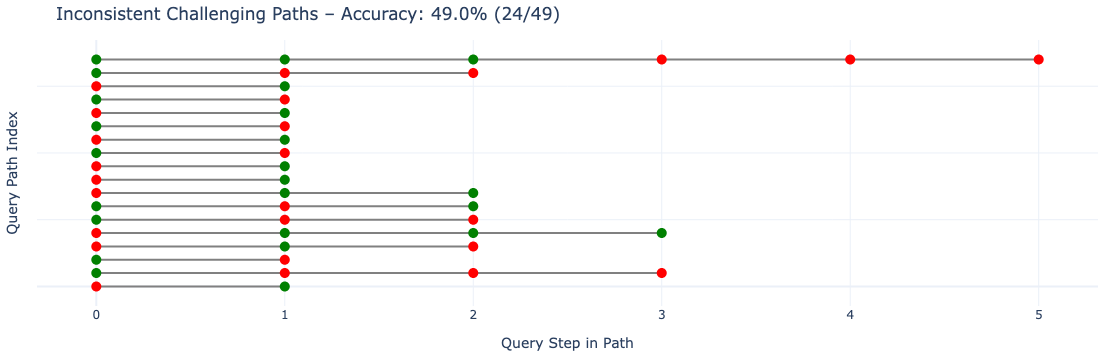

In [35]:
def plot_inconsistent_paths_by_difficulty(difficulty_level):
    fig = go.Figure()
    y_offset = 0

    def truncate(text, max_len=100):
        return text if len(text) <= max_len else text[:max_len] + "..."

    total = 0
    correct = 0

    for entry in data:
        path = entry["path"]
        if not path or path[0]["difficulty"] != difficulty_level:
            continue
        if len(path) <= 1:
            continue
        for step in path:
            if step['correct'] == None:
                step['correct'] = 0
        correct_count = sum(step['correct'] for step in path)
        if correct_count == 0 or correct_count == len(path):
            continue  # skip fully correct or fully wrong paths

        total += len(path)
        correct += correct_count

        x_vals = list(range(len(path)))
        y_vals = [y_offset] * len(path)
        colors = ['green' if step['correct'] == 1 else 'red' for step in path]
        hover_texts = [
            f"QID: {step['question_id']}<br>"
            f"<b>Difficulty:</b> {step['difficulty']}<br>"
            f"<b>Correct:</b> {'✅' if step['correct'] else '❌'}<br><br>"
            f"<b>GT:</b> {truncate(step['gt_query'])}<br><br>"
            f"<b>Pred:</b> {truncate(step['predicted_query'])}"
            for step in path
        ]

        fig.add_trace(go.Scatter(
            x=x_vals,
            y=y_vals,
            mode='lines+markers',
            marker=dict(color=colors, size=10),
            line=dict(color='gray', width=2),
            text=hover_texts,
            hoverinfo='text',
            showlegend=False
        ))

        y_offset += 1

    accuracy = (correct / total * 100) if total > 0 else 0

    fig.update_layout(
        title=f"Inconsistent {difficulty_level.capitalize()} Paths – Accuracy: {accuracy:.1f}% ({correct}/{total})",
        xaxis_title="Query Step in Path",
        yaxis_title="Query Path Index",
        yaxis=dict(showticklabels=False),
        template="plotly_white",
        height=400 + 50 * y_offset,
        margin=dict(l=20, r=20, t=40, b=20),
    )
    fig.show()

plot_inconsistent_paths_by_difficulty("challenging")